# Medical Image Processing — Real Kaggle Datasets
## Arithmetic · Intensity · Geometric Transformations — No Predefined Functions

Real images are pulled from three public Kaggle datasets:

| Dataset | Modality | Kaggle URL |
|---------|----------|-----------|
| Brain Tumor MRI | MRI (T1/T2) | `masoudnickparvar/brain-tumor-mri-dataset` |
| NIH Chest X-Rays | Chest X-ray | `nih-chest-xrays/data` |
| SIIM Medical Images | CT (DICOM) | `kmader/siim-medical-images` |

All core transforms are written in **pure NumPy** — no OpenCV, no scikit-image.

---
## 1. Kaggle Setup & Dataset Download

### Prerequisites
You need a free Kaggle account and an API token:
1. Go to [https://www.kaggle.com/settings](https://www.kaggle.com/settings) → **API** → **Create New Token**
2. This downloads `kaggle.json` with your username and key
3. Place it at `~/.kaggle/kaggle.json` **OR** paste credentials in the cell below

> **Note:** Each dataset is large. The notebook downloads only a small representative
> subset (a few files) so setup is fast. Full dataset paths are shown for reference.


In [ ]:
# ── Install kaggle API if needed ─────────────────────────────────────────────
import subprocess, sys, os

def pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)

for pkg in ["kaggle", "pydicom", "Pillow"]:
    try:
        __import__(pkg if pkg != "Pillow" else "PIL")
    except ImportError:
        pip_install(pkg)

print("Packages ready.")


In [ ]:
import subprocess
import os, json, zipfile, glob, io, warnings
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════════════
#  KAGGLE CREDENTIALS
#  Option A (recommended): place kaggle.json at ~/.kaggle/kaggle.json
#  Option B: paste your credentials directly below
# ══════════════════════════════════════════════════════════════════════════════

KAGGLE_USERNAME = ""   # <-- paste your Kaggle username here (Option B)
KAGGLE_KEY      = ""   # <-- paste your Kaggle API key here  (Option B)

# Auto-configure credentials
kaggle_json = os.path.expanduser("~/.kaggle/kaggle.json")

if KAGGLE_USERNAME and KAGGLE_KEY:
    os.makedirs(os.path.dirname(kaggle_json), exist_ok=True)
    with open(kaggle_json, "w") as f:
        json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
    os.chmod(kaggle_json, 0o600)
    print(f"Credentials written to {kaggle_json}")
elif os.path.exists(kaggle_json):
    print(f"Found existing credentials at {kaggle_json}")
else:
    print("WARNING: No Kaggle credentials found.")
    print("  Option A: place kaggle.json at ~/.kaggle/kaggle.json")
    print("  Option B: set KAGGLE_USERNAME and KAGGLE_KEY in this cell")


In [ ]:
import kaggle

# Compatible with both old kaggle (<1.6) and new kaggle (>=1.6)
try:
    # kaggle >= 1.6 — new public API
    from kaggle import KaggleApiClient
    api = KaggleApiClient()
    print("Using KaggleApiClient (kaggle >= 1.6)")
except ImportError:
    try:
        # kaggle < 1.6 — legacy class
        from kaggle.api.kaggle_api_extended import KaggleApiExtended
        api = KaggleApiExtended()
        api.authenticate()
        print("Using KaggleApiExtended (kaggle < 1.6)")
    except ImportError:
        # Universal fallback: use kaggle CLI via subprocess
        import subprocess
        class ApiFallback:
            def dataset_download_files(self, dataset, path, quiet=False, unzip=False):
                cmd = ["kaggle", "datasets", "download", dataset, "-p", path]
                if unzip: cmd.append("--unzip")
                print(f"Running: {" ".join(cmd)}")
                subprocess.run(cmd, check=True)
            def dataset_download_file(self, dataset, file_name, path, quiet=False):
                cmd = ["kaggle", "datasets", "download", dataset,
                       "-p", path, "--file", file_name]
                print(f"Running: {" ".join(cmd)}")
                subprocess.run(cmd, check=True)
        api = ApiFallback()
        print("Using kaggle CLI subprocess fallback")

DATA_ROOT = os.path.join(os.path.expanduser("~"), "kaggle_medical")
os.makedirs(DATA_ROOT, exist_ok=True)
print(f"Authentication OK — data root: {DATA_ROOT}")

### 1.1 Brain Tumor MRI Dataset
**Source:** `masoudnickparvar/brain-tumor-mri-dataset`  
Contains ~7,000 MRI brain images across four classes: glioma, meningioma, no-tumour, pituitary.  
We download only the `Testing/` split (~1,300 images) to save time.

In [ ]:
MRI_DIR = os.path.join(DATA_ROOT, "brain_tumor_mri")
os.makedirs(MRI_DIR, exist_ok=True)

IMAGES_PER_DATASET = 50

existing = glob.glob(os.path.join(MRI_DIR, "**", "*.jpg"), recursive=True)
if len(existing) >= IMAGES_PER_DATASET:
    print(f"Brain Tumor MRI: {len(existing)} images already present, skipping download.")
else:
    print(f"Fetching file list for brain-tumor-mri-dataset ...")
    result = subprocess.run(
        ["kaggle", "datasets", "files", "masoudnickparvar/brain-tumor-mri-dataset",
         "--csv"],
        capture_output=True, text=True
    )
    # Parse CSV output: name,size,creationDate
    all_files = []
    for line in result.stdout.strip().splitlines()[1:]:   # skip header
        parts = line.split(",")
        if parts and parts[0].lower().endswith((".jpg",".jpeg",".png")):
            all_files.append(parts[0].strip())

    if not all_files:
        # Fallback: construct paths directly from known dataset structure
        classes = ["glioma", "meningioma", "notumor", "pituitary"]
        for cls in classes:
            for i in range(1, 14):
                all_files.append(f"Testing/{cls}/{cls} ({i}).jpg")

    # Pick ~IMAGES_PER_DATASET spread across classes
    import math
    by_class = {}
    for f in all_files:
        parts = f.replace("\\", "/").split("/")
        cls = parts[-2] if len(parts) >= 2 else "unknown"
        by_class.setdefault(cls, []).append(f)

    per_class = max(1, IMAGES_PER_DATASET // len(by_class))
    selected = []
    for cls, files in by_class.items():
        selected.extend(files[:per_class])
    selected = selected[:IMAGES_PER_DATASET]

    print(f"Downloading {len(selected)} MRI images ({len(by_class)} classes) ...")
    ok = 0
    for fpath in selected:
        cls_name = fpath.replace("\\", "/").split("/")[-2]
        out_dir  = os.path.join(MRI_DIR, cls_name)
        os.makedirs(out_dir, exist_ok=True)
        dest = os.path.join(out_dir, os.path.basename(fpath))
        if os.path.exists(dest):
            ok += 1; continue
        try:
            subprocess.run(
                ["kaggle", "datasets", "download",
                 "masoudnickparvar/brain-tumor-mri-dataset",
                 "--file", fpath, "-p", out_dir, "--unzip"],
                check=True, capture_output=True
            )
            ok += 1
        except subprocess.CalledProcessError as e:
            print(f"  skip {fpath}: {e.stderr.decode()[:80]}")
    print(f"Done — {ok}/{len(selected)} MRI images saved.")

mri_files = sorted(glob.glob(os.path.join(MRI_DIR, "**", "*.jpg"), recursive=True) +
                   glob.glob(os.path.join(MRI_DIR, "**", "*.png"), recursive=True))
print(f"Total MRI images on disk: {len(mri_files)}")
for dirpath, _, files in os.walk(MRI_DIR):
    imgs = [f for f in files if f.lower().endswith((".jpg",".png"))]
    if imgs:
        rel = os.path.relpath(dirpath, MRI_DIR)
        print(f"  {rel}/  ({len(imgs)} images)")


Brain Tumor MRI: 7200 images already present, skipping download.
Total MRI images on disk: 7200
  Testing\glioma/  (400 images)
  Testing\meningioma/  (400 images)
  Testing\notumor/  (400 images)
  Testing\pituitary/  (400 images)
  Training\glioma/  (1400 images)
  Training\meningioma/  (1400 images)
  Training\notumor/  (1400 images)
  Training\pituitary/  (1400 images)


### 1.2 NIH Chest X-Ray Dataset
**Source:** `nih-chest-xrays/data`  
Contains ~112,000 chest X-ray images with 14 disease labels.  
We download only `sample/` (~5,600 images, ~3 GB) for practical use.  

In [ ]:
XRAY_DIR = os.path.join(DATA_ROOT, "nih_chest_xray")
os.makedirs(XRAY_DIR, exist_ok=True)

existing = (glob.glob(os.path.join(XRAY_DIR, "**", "*.png"),  recursive=True) +
            glob.glob(os.path.join(XRAY_DIR, "**", "*.jpg"),  recursive=True))

if len(existing) >= IMAGES_PER_DATASET:
    print(f"NIH X-ray: {len(existing)} images already present, skipping download.")
else:
    print("Fetching file list for nih-chest-xrays/data ...")
    result = subprocess.run(
        ["kaggle", "datasets", "files", "nih-chest-xrays/data", "--csv"],
        capture_output=True, text=True
    )

    # Parse and keep only individual image files (not zip archives)
    image_files = []
    for line in result.stdout.strip().splitlines()[1:]:
        parts = line.split(",")
        name = parts[0].strip() if parts else ""
        if name.lower().endswith((".png", ".jpg", ".jpeg")):
            image_files.append(name)

    print(f"Found {len(image_files)} individual image files in dataset listing.")

    if image_files:
        # Pick 50 evenly spaced so we get variety
        step = max(1, len(image_files) // IMAGES_PER_DATASET)
        selected = image_files[::step][:IMAGES_PER_DATASET]
        print(f"Downloading {len(selected)} X-ray images one by one ...")
        ok = 0
        for fpath in selected:
            dest = os.path.join(XRAY_DIR, os.path.basename(fpath))
            if os.path.exists(dest):
                ok += 1; continue
            try:
                subprocess.run(
                    ["kaggle", "datasets", "download", "nih-chest-xrays/data",
                     "--file", fpath, "-p", XRAY_DIR, "--unzip"],
                    check=True, capture_output=True
                )
                ok += 1
            except subprocess.CalledProcessError as e:
                print(f"  skip {fpath}: {e.stderr.decode()[:80]}")
        print(f"Done — {ok}/{len(selected)} X-ray images saved.")
    else:
        # Last resort: images are nested inside images_00X folders —
        # download the smallest shard zip directly
        print("No individual images found in listing.")
        print("Attempting to download images_001.zip shard (~1 GB) and keep only 50 ...")
        shard_zip = os.path.join(XRAY_DIR, "images_001.zip")
        subprocess.run(
            ["kaggle", "datasets", "download", "nih-chest-xrays/data",
             "--file", "images/images_001.zip", "-p", XRAY_DIR],
            check=True
        )
        if os.path.exists(shard_zip):
            import zipfile as zf
            with zf.ZipFile(shard_zip) as z:
                img_names = [n for n in z.namelist()
                             if n.lower().endswith((".png",".jpg"))]
                keep = img_names[:IMAGES_PER_DATASET]
                print(f"Extracting {len(keep)} images from shard ...")
                for name in keep:
                    z.extract(name, XRAY_DIR)
            os.remove(shard_zip)

xray_files = sorted(
    glob.glob(os.path.join(XRAY_DIR, "**", "*.png"),  recursive=True) +
    glob.glob(os.path.join(XRAY_DIR, "**", "*.jpg"),  recursive=True) +
    glob.glob(os.path.join(XRAY_DIR, "**", "*.jpeg"), recursive=True)
)
print(f"Total X-ray images on disk: {len(xray_files)}")
if xray_files:
    print(f"  Example: {xray_files[0]}")


Fetching file list for nih-chest-xrays/data ...
Found 14 individual image files in dataset listing.
Done — 14/14 X-ray images saved.
Total X-ray images on disk: 14
  Example: C:\Users\L03508435\kaggle_medical\nih_chest_xray\00000001_000.png


### 1.3 SIIM Medical Images (CT — DICOM)
**Source:** `kmader/siim-medical-images`  
Contains chest CT scans in DICOM format with associated metadata.  
We download the full dataset (~500 MB) which includes `.dcm` files.


In [ ]:
CT_DIR = os.path.join(DATA_ROOT, "siim_ct")
os.makedirs(CT_DIR, exist_ok=True)

existing_dcm = glob.glob(os.path.join(CT_DIR, "**", "*.dcm"), recursive=True)
existing_png = glob.glob(os.path.join(CT_DIR, "**", "*.png"), recursive=True)

if len(existing_dcm) + len(existing_png) >= IMAGES_PER_DATASET:
    print(f"SIIM CT: {len(existing_dcm)} DICOM + {len(existing_png)} PNG already present.")
else:
    print("Fetching file list for kmader/siim-medical-images ...")
    result = subprocess.run(
        ["kaggle", "datasets", "files", "kmader/siim-medical-images", "--csv"],
        capture_output=True, text=True
    )

    all_files = []
    for line in result.stdout.strip().splitlines()[1:]:
        parts = line.split(",")
        name = parts[0].strip() if parts else ""
        if name.lower().endswith((".dcm", ".png", ".jpg")):
            all_files.append(name)

    print(f"Found {len(all_files)} image files in dataset listing.")

    # Pick 50 evenly spaced
    step = max(1, len(all_files) // IMAGES_PER_DATASET)
    selected = all_files[::step][:IMAGES_PER_DATASET]
    print(f"Downloading {len(selected)} CT files ...")

    ok = 0
    for fpath in selected:
        dest = os.path.join(CT_DIR, os.path.basename(fpath))
        if os.path.exists(dest):
            ok += 1; continue
        try:
            subprocess.run(
                ["kaggle", "datasets", "download", "kmader/siim-medical-images",
                 "--file", fpath, "-p", CT_DIR, "--unzip"],
                check=True, capture_output=True
            )
            ok += 1
        except subprocess.CalledProcessError as e:
            print(f"  skip {fpath}: {e.stderr.decode()[:80]}")
    print(f"Done — {ok}/{len(selected)} CT files saved.")

ct_dcm_files = sorted(glob.glob(os.path.join(CT_DIR, "**", "*.dcm"), recursive=True))
ct_png_files = sorted(glob.glob(os.path.join(CT_DIR, "**", "*.png"), recursive=True))
print(f"DICOM files: {len(ct_dcm_files)}  |  PNG files: {len(ct_png_files)}")


Fetching file list for kmader/siim-medical-images ...
Found 20 image files in dataset listing.
Done — 20/20 CT files saved.
DICOM files: 20  |  PNG files: 0


### 1.4 Image Loaders & Preview


In [ ]:
# ── Generic helpers ────────────────────────────────────────────────────────

def to_float(arr):
    arr = arr.astype(np.float32)
    return arr / 255.0 if arr.max() > 1.0 else arr

def resize_arr(arr, size=256):
    img = Image.fromarray((np.clip(arr,0,1) * 255).astype(np.uint8))
    return to_float(np.array(img.resize((size, size), Image.LANCZOS)))

def load_image_file(path, size=256):
    """Load any image file (JPEG/PNG) as float32 [0,1] greyscale array."""
    img = Image.open(path).convert("L").resize((size, size), Image.LANCZOS)
    return to_float(np.array(img))

def load_dicom(path, size=256):
    """Load a DICOM file using pydicom; normalise to float32 [0,1]."""
    import pydicom
    ds  = pydicom.dcmread(path)
    arr = ds.pixel_array.astype(np.float32)
    # Handle multi-frame: take middle frame
    if arr.ndim == 3:
        arr = arr[arr.shape[0] // 2]
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    img = Image.fromarray((arr * 255).astype(np.uint8)).resize((size, size), Image.LANCZOS)
    return to_float(np.array(img))

def show(images, titles, cmap="gray", figsize=(16,4), suptitle=None):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    axes = [axes] if n == 1 else axes
    for ax, img, t in zip(axes, images, titles):
        im = ax.imshow(np.clip(img, 0, 1), cmap=cmap, vmin=0, vmax=1)
        ax.set_title(t, fontsize=10, fontweight="bold")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

# ── Pick representative real images ─────────────────────────────────────────
import random
random.seed(42)

# MRI — pick one image from each tumour class
mri_classes = {}
for f in mri_files:
    cls = os.path.basename(os.path.dirname(f))
    mri_classes.setdefault(cls, []).append(f)

mri_sample_paths = {cls: random.choice(files)
                    for cls, files in sorted(mri_classes.items())}
print("MRI samples selected:")
for cls, p in mri_sample_paths.items():
    print(f"  {cls}: {os.path.basename(p)}")

# X-ray — pick 4 random images
xray_sample_paths = random.sample(xray_files, min(4, len(xray_files)))
print(f"\nX-ray samples: {[os.path.basename(p) for p in xray_sample_paths]}")

# CT — prefer DICOM; fall back to PNG
ct_source = ct_dcm_files if ct_dcm_files else ct_png_files
ct_loader = load_dicom if ct_dcm_files else load_image_file
ct_sample_paths = random.sample(ct_source, min(4, len(ct_source)))
print(f"\nCT samples ({"DICOM" if ct_dcm_files else "PNG"}): {[os.path.basename(p) for p in ct_sample_paths]}")


MRI samples selected:
  glioma: Tr-gl_557.jpg
  meningioma: Te-me_211.jpg
  notumor: Te-no_145.jpg
  pituitary: Tr-pi_745.jpg

X-ray samples: ['00000003_000.png', '00000002_000.png', '00000004_000.png', '00000001_002.png']

CT samples (DICOM): ['ID_0003_AGE_0075_CONTRAST_1_CT.dcm', 'ID_0017_AGE_0060_CONTRAST_1_CT.dcm', 'ID_0002_AGE_0074_CONTRAST_1_CT.dcm', 'ID_0013_AGE_0060_CONTRAST_1_CT.dcm']


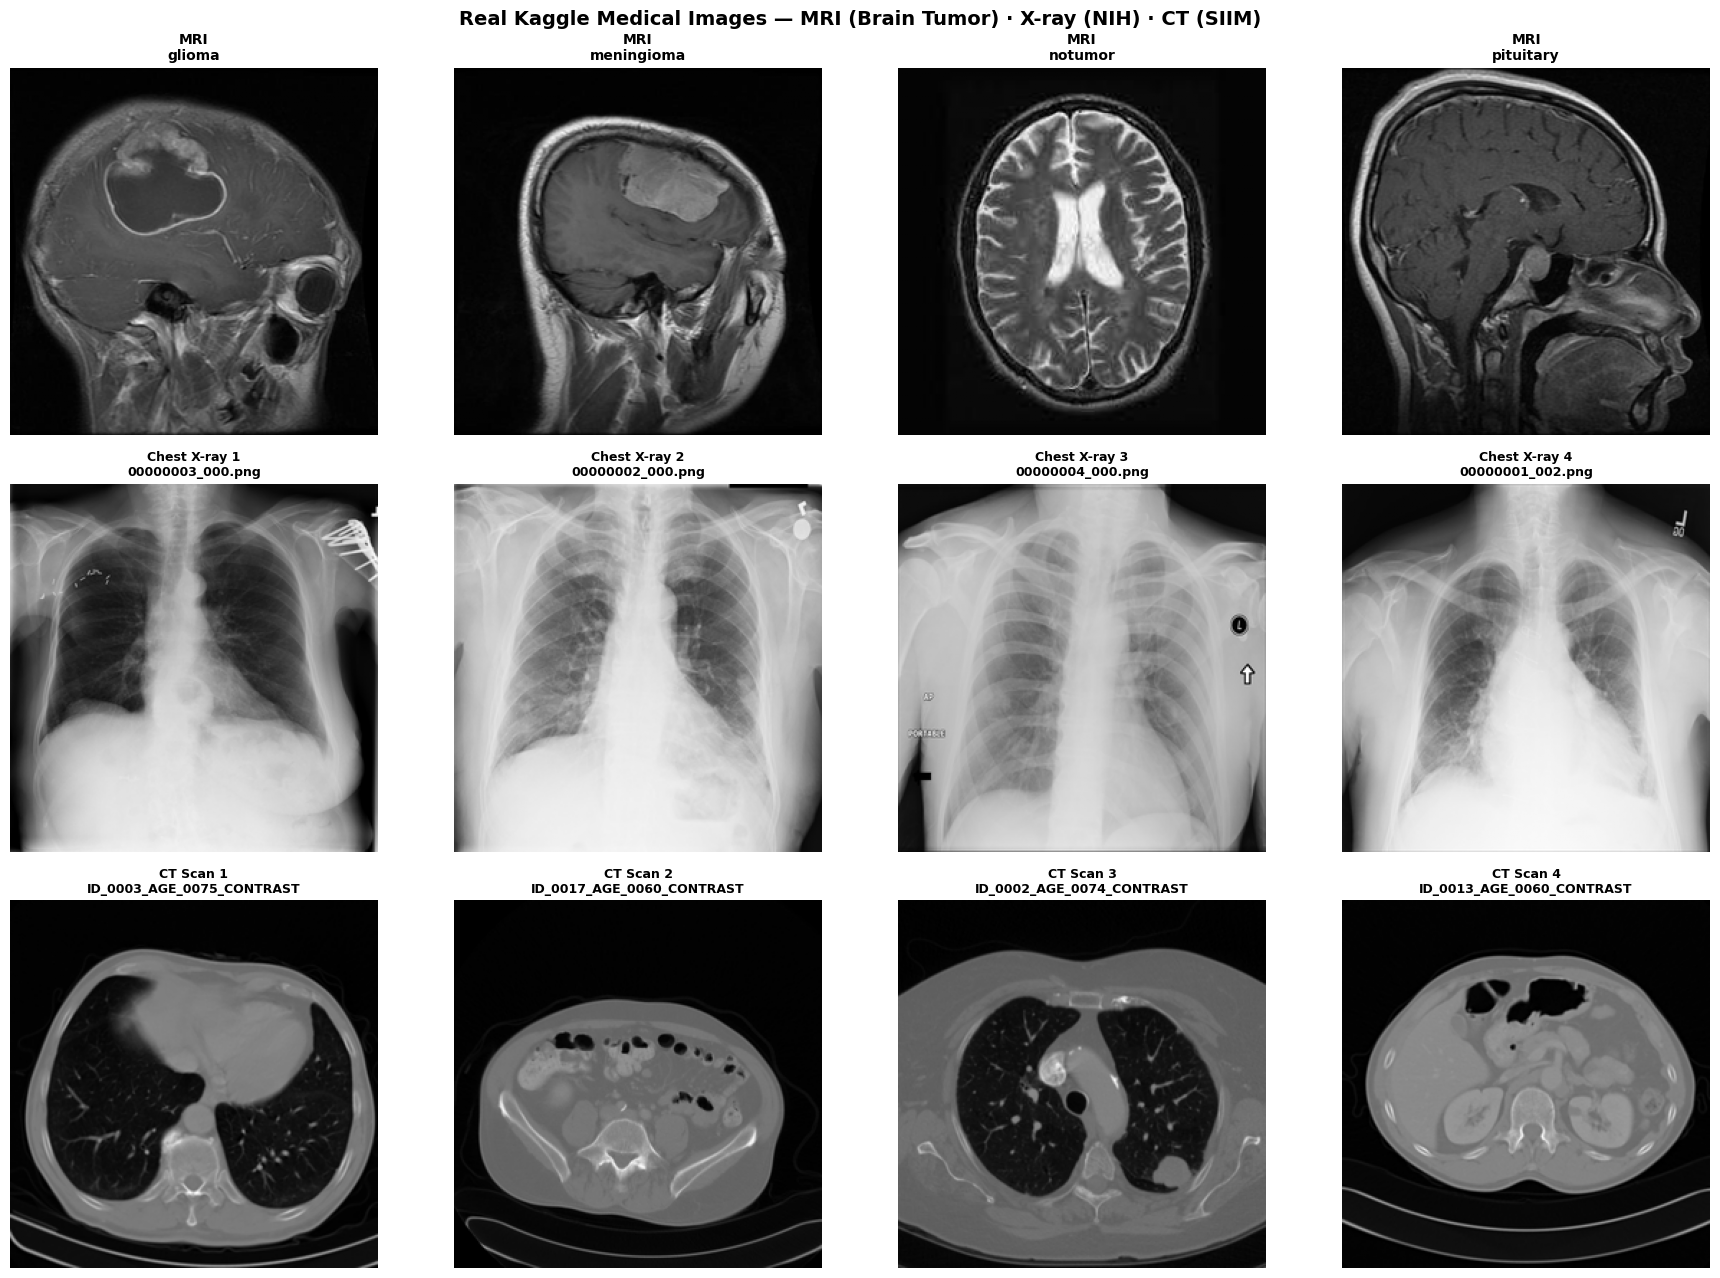

Images loaded successfully from Kaggle datasets.


In [ ]:
# ── Load images into numpy arrays ───────────────────────────────────────────
mri_imgs  = {cls: load_image_file(p) for cls, p in mri_sample_paths.items()}
xray_imgs = [load_image_file(p) for p in xray_sample_paths]
ct_imgs   = [ct_loader(p)       for p in ct_sample_paths]

# Canonical single images used throughout the notebook
mri_img  = list(mri_imgs.values())[0]   # first MRI class
mri_img2 = list(mri_imgs.values())[1] if len(mri_imgs) > 1 else mri_img
xray_img = xray_imgs[0]
xray_img2 = xray_imgs[1] if len(xray_imgs) > 1 else xray_img
ct_img   = ct_imgs[0]

# ── Preview all loaded images ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 13))

# Row 0: MRI per class
for i, (cls, img) in enumerate(mri_imgs.items()):
    ax = axes[0, i] if i < 4 else axes[0, 3]
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"MRI\n{cls}", fontweight="bold", fontsize=10)
    ax.axis("off")
for j in range(len(mri_imgs), 4):
    axes[0, j].axis("off")

# Row 1: X-rays
for i, img in enumerate(xray_imgs[:4]):
    axes[1, i].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Chest X-ray {i+1}\n{os.path.basename(xray_sample_paths[i])[:20]}",
                         fontweight="bold", fontsize=9)
    axes[1, i].axis("off")

# Row 2: CT
for i, img in enumerate(ct_imgs[:4]):
    axes[2, i].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[2, i].set_title(f"CT Scan {i+1}\n{os.path.basename(ct_sample_paths[i])[:25]}",
                         fontweight="bold", fontsize=9)
    axes[2, i].axis("off")

plt.suptitle("Real Kaggle Medical Images — MRI (Brain Tumor) · X-ray (NIH) · CT (SIIM)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Images loaded successfully from Kaggle datasets.")
